In [1]:
import os

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

## __Examples: Introduction to data visualisation__

In this notebook, we will explore data visualisation using Python's Matplotlib package. We will learn how to implement various plotting techniques, distinguish between graph types, and choose the best visual representation for data.

### __Learning objectives__
By the end of this notebook, you should be able to:

* Implement various plotting techniques using Python's Matplotlib package.
* Distinguish between different types of graphs.
* Understand how to best represent data using a specific graph.
* Analyse and draw insights from graphs.

### __Introduction__

Data visualisation is the process of presenting data and information in graphical forms such as charts, maps, and diagrams. The goal of these graphics is to improve understanding of the underlying data by making patterns, trends, correlations, and outliers more visible than a simple study of the raw data.

There may be numerous occasions when we will need to share our data-driven results and insights. Unfortunately, raw data are not appropriate for this purpose. This is where maximising the potential of data visualisation becomes critical. In this notebook, we will learn how to visualise data using Python's graphing library, Matplotlib, as well as how to identify the appropriate visualisation approaches to apply based on the data we are given.

There are many different ways to represent the same data, and the choice of visualisation affects what information is conveyed to the audience. In this notebook, review some of the most basic (yet useful and reliable) chart options.

Below is an image depicting some of the most popular charts used for data visualisation.

<center><img src="https://raw.github.com/Explore-AI/Pictures/master/Introduction_to_data_visualisation_edit.jpeg?raw=true" style="float: center; padding-bottom=0.5em" width=80%/></center>

### __Load the Data__

[data source]("https://cdn.alx-ai-tools.com/marimo/v2/data/Data/tips.csv")

In [2]:
file_path = "../data"

path = os.path.join(file_path, "tips.csv")
tips = pd.read_csv(path)

### __Data preparation__

Preparing data before plotting in Python is essential for various reasons. Initially, data may not be in a suitable format for direct plotting, necessitating tasks such as restructuring DataFrames and handling missing values. Additionally, data cleaning and quality assurance steps, including outlier removal and imputing missing values, ensure the accuracy of visualisations. Grouping, slicing, and aggregating the data play crucial roles in this process, allowing for the categorisation of data based on specific criteria, extraction of relevant subsets, and the creation of summarised perspectives through aggregation functions like sum, mean, or count.

By addressing these aspects during data preparation, we can optimise the data for meaningful visualisations, improving the accuracy and interpretability of insights drawn from the plotted data.

In [3]:
tips.head()

,total_bill,tip,sex,smoker,day,time,size
0,16.99,1.01,Female,No,Sun,Dinner,2
1,10.34,1.66,Male,No,Sun,Dinner,3
2,21.01,3.50,Male,No,Sun,Dinner,3
3,23.68,3.31,Male,No,Sun,Dinner,2
4,24.59,3.61,Female,No,Sun,Dinner,4


In [4]:
# group and sum the data by the number of values for each ‘day’
title_day = tips.groupby('day')[
    ['total_bill','tip','size']
    ].sum() 
title_day

,total_bill,tip,size
day,,,
Fri,325.88,51.96,40
Sat,1778.40,260.40,219
Sun,1627.16,247.39,216
Thur,1096.33,171.83,152


In [5]:
def save_plot(
    save,
    filename,
    save_folder="images"
):
    """
    Saves the current Matplotlib figure to a specified folder if save=True.
    """
    if save:
        os.makedirs(save_folder, exist_ok=True)

        plt.savefig(
            f"{save_folder}/{filename}.png",
            dpi=120,
            bbox_inches="tight"
        )

In [6]:
def style_axes(
    ax,
    title,
    xlabel,
    ylabel,
    grid_color="0.75"
):
    plt.rcParams.update({
        "axes.titlesize": 13,
        "axes.titleweight": "bold",
        "axes.labelsize": 12,
        "xtick.labelsize": 10,
        "ytick.labelsize": 10,
        "legend.fontsize": 10
    })

    ax.set_title(title, pad=12)
    ax.set_xlabel(xlabel)
    ax.set_ylabel(ylabel)

    ax.set_axisbelow(True)

    ax.grid(
        True,
        color=grid_color,
        linestyle="--",
        linewidth=0.8,
        alpha=0.4
    )

    for spine in ax.spines.values():
        spine.set_visible(False)

    ax.tick_params(length=0)
    plt.tight_layout()

__Bar Plot__

From the data provided, we can find out which days of the week the restaurant was the busiest and made the most amount of money.

We can visualise this data using a bar graph as follows:

In [20]:
def barplot(
    df,
    x,
    y,
    title=None,
    xlabel=None,
    ylabel=None,
    order=None,
    hue=None,
    palette=None,
    color=None,
    annotate=False,
    save=False
):

    fig, ax = plt.subplots(figsize=(8,4))

    if hue is not None and palette is None:
        palette = "viridis"

    elif hue is None and color is None:
        color = "steelblue"


    sns.barplot(
        data=df,
        x=x,
        y=y,
        order=order,
        width=0.2,
        color=color,
        errorbar=None,
        hue=hue,
        palette=palette,
        ax=ax
    )


    if annotate == True:
        for container in ax.containers:
            ax.bar_label(
                container,
                fmt="%.1f",
                fontsize=10
            )


    style_axes(
        ax,
        title=title or f"{y} by {x}",
        xlabel=xlabel or x,
        ylabel=ylabel or y
    )
    plt.xticks(rotation=30)

    save_plot(
        save,
        f"barplot_of_{x}_and_{y}"
    )

    plt.show()

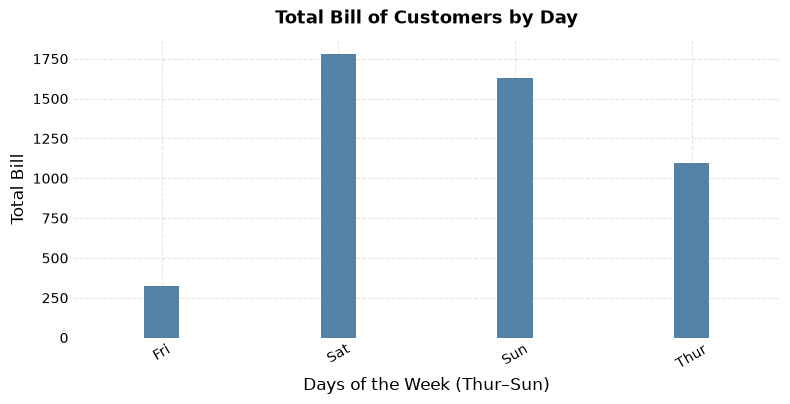

In [21]:
bill_per_day = (
    tips.groupby("day", as_index=False)["total_bill"]
        .sum()
)


barplot(
    df=bill_per_day,
    x="day",
    y="total_bill",
    title="Total Bill of Customers by Day",
    xlabel="Days of the Week (Thur–Sun)",
    ylabel="Total Bill"
)

__Insights:__

- Saturday has the largest total bill, making it the restaurant's highest-revenue day.
- This suggests that customer demand and spending peak on Saturdays.

__Total Revenue by Time__

     time  total_bill
0  Dinner     3660.30
1   Lunch     1167.47



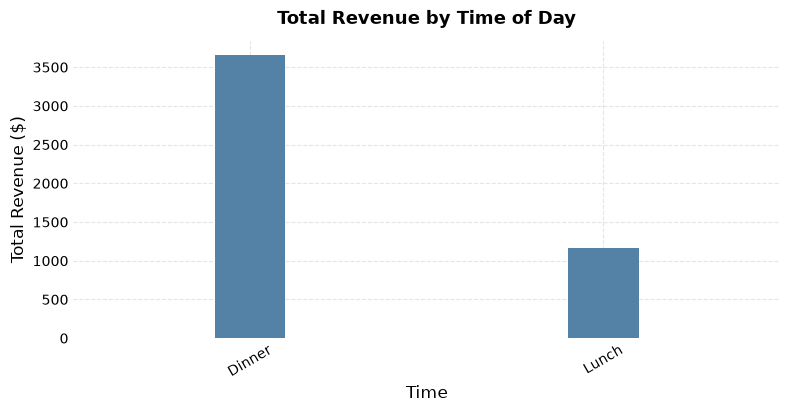

In [23]:
revenue_time = (
    tips.groupby("time")["total_bill"]
    .sum()
    .reset_index()
)

print(revenue_time)

print()

barplot(
    df=revenue_time,
    x="time",
    y="total_bill",
    title="Total Revenue by Time of Day",
    xlabel="Time",
    ylabel="Total Revenue ($)"
)

__Insights:__

- Dinner generates over three times the revenue of lunch.
- This aligns with the earlier pie chart, where 72.1% of customers visited during dinner

__Scatter Plot__

In [24]:
def scatterplot(
    df,
    x,
    y,
    title=None,
    xlabel=None,
    ylabel=None,
    hue=None,
    size=None,
    alpha=0.7,
    save=False,
    save_folder="images"
):
    """
    Create a scatter plot with consistent styling.
    """
    fig, ax = plt.subplots(figsize=(8, 4))

    sns.scatterplot(
        data=df,
        x=x,
        y=y,
        hue=hue,
        palette="viridis" if hue else None,
        size=size,
        sizes=(20, 200),  # Scale marker size range smoothly
        alpha=alpha,
        edgecolor="black",
        linewidth=0.4,
        ax=ax
    )

    # Determine labels and titles dynamically
    plot_title = title if title else f"{y.replace('_', ' ').title()} vs {x.replace('_', ' ').title()}"
    plot_xlabel = xlabel if xlabel else x.replace('_', ' ').title()
    plot_ylabel = ylabel if ylabel else y.replace('_', ' ').title()

    # Apply global styling
    style_axes(
        ax,
        title=plot_title,
        xlabel=plot_xlabel,
        ylabel=plot_ylabel
    )

    # Position legend neatly outside or on top right
    if hue or size:
        ax.legend(bbox_to_anchor=(1.05, 1), loc='upper left', frameon=False)

    save_plot(
        save,
        f"{y}_vs_{x}",
        save_folder=save_folder
    )

    plt.show()

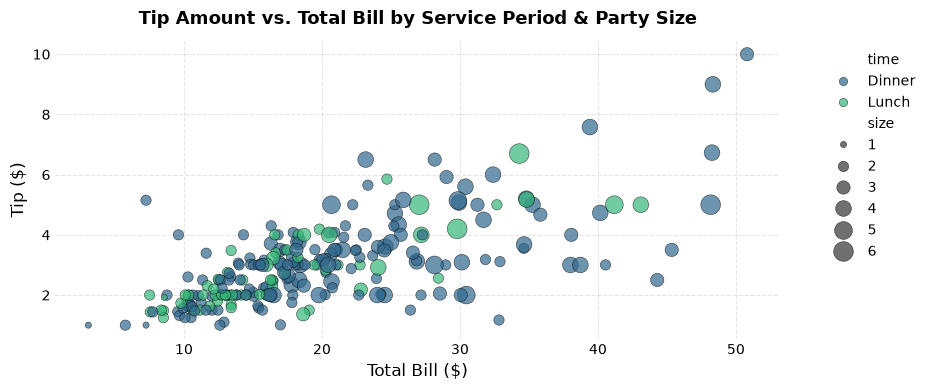

In [25]:
# Run the plot
scatterplot(
    df=tips,
    x="total_bill",
    y="tip",
    hue="time",
    size="size",
    title="Tip Amount vs. Total Bill by Service Period & Party Size",
    xlabel="Total Bill ($)",
    ylabel="Tip ($)",
    save=False
)

__Insights:__

- Higher total bills reliably correlate with higher tip amounts, adhering closely to the standard 15–20% tipping norm.
- Almost all bills exceeding `$30` and tips exceeding `$6` occur during Dinner service.
- Larger party sizes (indicated by larger marker sizes) naturally sit in the upper-right quadrant of total spend and tipping.

__Line Plot__

In [14]:
def lineplot(
    df,
    x,
    y,
    title=None,
    xlabel=None,
    ylabel=None,
    hue=None,
    style=None,
    marker="o",
    linewidth=2,
    alpha=0.8,
    save=False
):
    """
    Create a line plot with consistent styling.

    Parameters
    ----------
    df : pandas.DataFrame
        Dataset containing the variables.
    x : str
        Column name for x-axis.
    y : str
        Column name for y-axis.
    hue : str, optional
        Column used to create multiple lines.
    style : str, optional
        Column used to change line style.
    marker : str
        Marker style for data points.
    linewidth : float
        Width of the line.
    alpha : float
        Line transparency.
    save : bool
        Whether to save the figure.
    """

    fig, ax = plt.subplots()

    sns.lineplot(
        data=df,
        x=x,
        y=y,
        hue=hue,
        style=style,
        marker=marker,
        linewidth=linewidth,
        alpha=alpha,
        ax=ax
    )

    style_axes(
        ax,
        title=f"{y} over {x}",
        xlabel=x,
        ylabel=y
    )

    save_plot(
        save,
        f"lineplot_{y}_over_{x}"
    )

    plt.show()

__Pie Plot__

In [26]:
def pieplot(
    df,
    column,
    title=None,
    autopct="%1.1f%%",
    startangle=90,
    explode=None,
    save=False,
    save_folder="images"
):
    """
    Create a clean, professional pie chart showing category proportions.
    
    Parameters:
    - df: DataFrame containing the data.
    - column: Column name to visualize.
    - title: Optional title for the chart.
    - autopct: String format for percentages.
    - startangle: Rotation angle to start the first slice.
    - explode: Tuple specifying slice offsets (e.g., (0.1, 0, 0) to pull out the first slice).
    - save: Boolean, whether to save the figure.
    - save_folder: Directory to save the plot image.
    """
    fig, ax = plt.subplots(figsize=(6, 4))

    # Count categories and sort descending
    counts = df[column].value_counts().sort_values(ascending=False)

    # Create pie chart
    wedges, texts, autotexts = ax.pie(
        counts.values,
        labels=counts.index,
        autopct=autopct,
        startangle=startangle,
        explode=explode,
        pctdistance=0.7,
        labeldistance=1.1,
        wedgeprops={
            "edgecolor": "white",
            "linewidth": 2
        }
    )

    # Style percentage labels inside slices
    for autotext in autotexts:
        autotext.set_fontsize(10)
        autotext.set_weight("bold")
        autotext.set_color("white")

    # Set Title
    plot_title = title if title else f"Distribution of {column}"
    
    # Apply global styling
    style_axes(ax, title=plot_title, xlabel="", ylabel="")
    
    # Clean up axes for circular plot
    ax.grid(False)
    ax.set_xticks([])
    ax.set_yticks([])
    ax.axis("equal")

    # Save and display
    save_plot(save, f"pieplot_{column}", save_folder=save_folder)
    plt.show()

__Question:__
- __When should the restaurant allocate more staff and resources?__

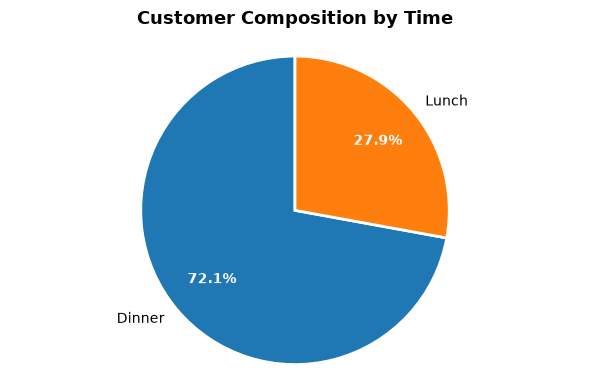

In [27]:
pieplot(
    tips,
    "time",
    title="Customer Composition by Time",
    save=False
)

__Insight__

The restaurant's customer traffic is heavily concentrated during dinner service, which accounts for 72.1% of visits. This suggests that operational resources such as staffing, inventory, and table availability should be prioritized during evening hours. However, the lower lunch-time customer share presents an opportunity to increase revenue through targeted promotions and improved lunch offerings.

__Donut Plot__

In [28]:
def donutplot(
    df,
    column,
    title=None,
    autopct="%1.1f%%",
    startangle=90,
    save=False,
    save_folder="images"
):
    """
    Create a professional donut chart showing category proportions.
    """
    fig, ax = plt.subplots(figsize=(6, 4))

    # Count categories and sort descending
    counts = df[column].value_counts().sort_values(ascending=False)
    total = counts.sum()

    # Create donut
    wedges, texts, autotexts = ax.pie(
        counts.values,
        labels=counts.index,
        autopct=autopct,
        startangle=startangle,
        pctdistance=1.15,
        labeldistance=1.40,
        wedgeprops={
            "width": 0.35,
            "edgecolor": "white",
            "linewidth": 2
        }
    )

    # Improve percentage text styling
    for autotext in autotexts:
        autotext.set_fontsize(9)
        autotext.set_weight("bold")

    # Center KPI
    ax.text(
        0,
        0,
        f"{total}\nCustomers",
        ha="center",
        va="center",
        fontsize=16,
        fontweight="bold"
    )

    # Determine plot title
    plot_title = title if title else f"Distribution of {column}"

    # Apply global styling helper function
    style_axes(ax, title=plot_title, xlabel="", ylabel="")

    # Turn off grid lines and ticks specifically for donut visual cleaness
    ax.grid(False)
    ax.set_xticks([])
    ax.set_yticks([])
    ax.axis("equal")

    # Save and display
    save_plot(save, f"donutplot_{column}", save_folder=save_folder)
    plt.show()

__Question:__
- __When is the restaurant busiest?__

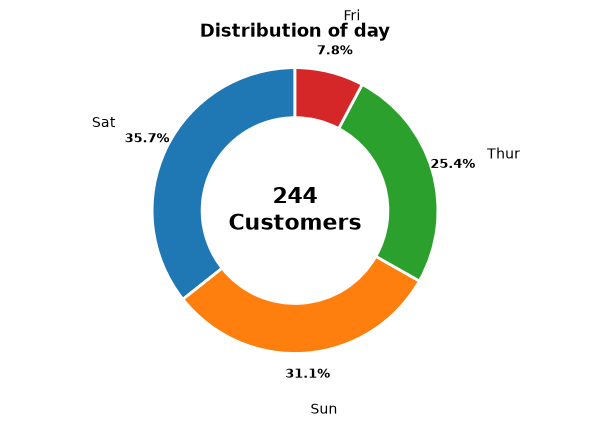

In [29]:
donutplot(
    tips,
    "day"
)

__Insight:__

Saturday represents the largest customer segment (35.7%), followed by Sunday (31.1%). Together, weekend customers account for approximately two-thirds of restaurant traffic, suggesting that staffing, inventory preparation, and promotions should prioritize weekend operations.

__Heat Map__

#### __Time Analysis__

In [30]:
time_analysis = (
    tips.groupby("time")
    .agg(
        Customers=("total_bill", "count"),
        Average_Bill=("total_bill", "mean"),
        Total_Revenue=("total_bill", "sum")
    )
    .reset_index()
)

time_analysis

,time,Customers,Average_Bill,Total_Revenue
0,Dinner,176,20.797159,3660.30
1,Lunch,68,17.168676,1167.47


__Insights__

- Dinner is the restaurant's strongest revenue period because it combines higher customer volume with strong average spending. Therefore, operational resources such as staff scheduling, food preparation, and table management should prioritize dinner hours
- 

#### __Business Recommendation__
- Dinner is the restaurant's most important operating period, accounting for the majority of both customer visits and total revenue. Resources such as staff scheduling, food preparation, and seating capacity should therefore be concentrated during dinner service to maximize efficiency and customer satisfaction. Conversely, lunch represents an opportunity for business growth, where targeted promotions and tailored menu offerings could increase customer traffic and overall sales.
- Inventory Management: Allocate roughly `70–75%` of daily perishable prep to dinner to minimize mid-service stockouts and reduce lunch-hour food waste.
- Express Menu / Business Lunch Specials: Speed is key for lunch customers. Introduce pre-set, quick-prep combos to increase table turnover and capture local workforce demand.
- Targeted Promotions: Offer `Lunch-Only` loyalty perks or discounts during off-peak hours to boost foot traffic without diluting dinner margins.
- pselling high-margin menu items (e.g., appetizers, specialty cocktails, and premium entrees) directly boosts server compensation and employee retention without requiring extra table volume.
- Optimize floor management to accommodate party sizes of 4+ efficiently during dinner shifts. Consider auto-gratuity policies for large groups (e.g., parties of 6+) to guarantee baseline service compensation for complex table management.
- The restaurant's revenue is heavily concentrated on the weekend, with Saturday generating the highest total sales, followed closely by Sunday. This indicates that staffing, inventory, and operational resources should be prioritized during the weekend to accommodate higher customer demand. In contrast, Friday presents the greatest opportunity for revenue growth, suggesting that targeted promotions and marketing initiatives could help increase customer traffic and sales.
